In [2]:
#%pip install librosa

In [3]:
#get specific audio file and check its length
import librosa

file = "train_soundscapes/BC2026_Train_0001_S08_20250606_030007.ogg"

y, sr = librosa.load(file, sr=None)

print("Audio length:", len(y)/sr, "seconds")

c:\Users\bulle\anaconda3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Audio length: 60.0 seconds


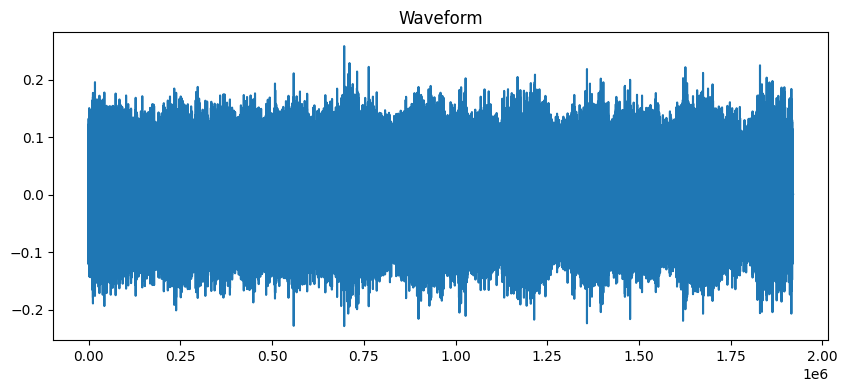

In [4]:
#visualize the waveform
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("Waveform")
plt.show()

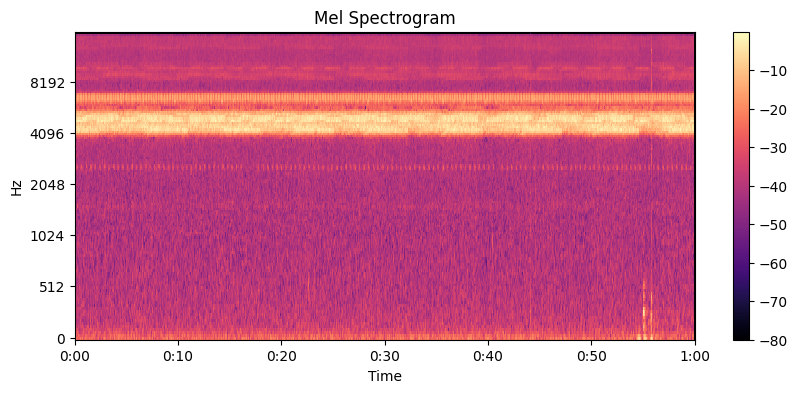

In [5]:
#visualize the spectrogram
import numpy as np
import librosa.display

S = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

In [6]:
#initial thoughts

#lower frequency don't get affected by the terrain as much as higher frequencies, so if ml model learns primarily lower frequencies, 
# this might lead to worse classification for higher frequency animals if applied. 
# Higher frequencies are more likely to be affected by the terrain




#we need to explore the variation in frequency for each location and see the variance in species frequencies compared to normal recordings of the species
#more than likely the species audio recording are taken in ideal conditions compared to this   




In [7]:
import pandas as pd
import numpy as np
train = pd.read_csv("train.csv")

In [8]:
#explore labels
train.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [9]:
#how to connect the audio files to the labels?

#we have audio of the species in the train_audio and we have audio from recorders 

#each recorder will have that background noise hopefully constant, so that is an assumption

In [10]:
#%pip install geopandas

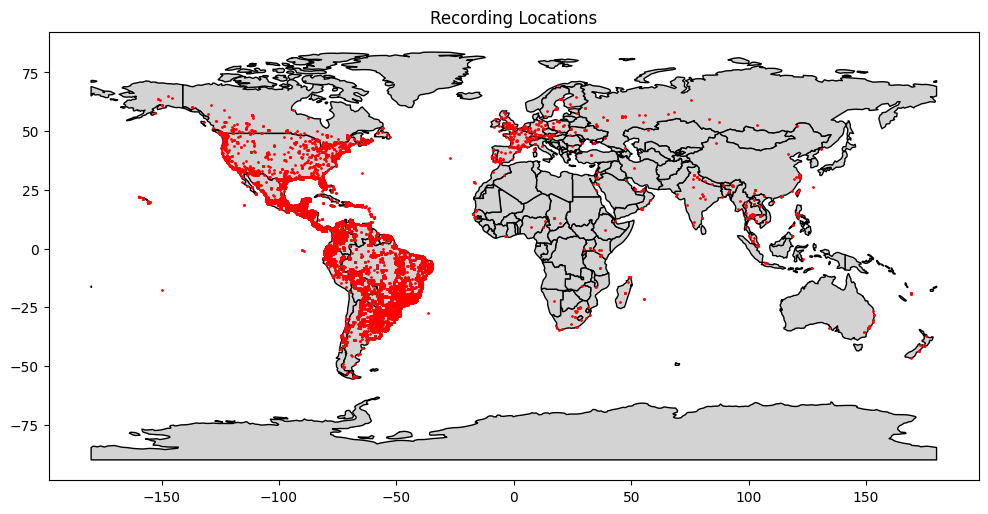

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file("maps/ne_110m_admin_0_countries.shp")

gdf = gpd.GeoDataFrame(
    train,
    geometry=gpd.points_from_xy(train.longitude, train.latitude)
)

ax = world.plot(figsize=(12,6), color="lightgray", edgecolor="black")
gdf.plot(ax=ax, markersize=1, color="red")

plt.title("Recording Locations")
plt.show()

In [12]:
#train_audio is recording of the species



In [13]:
#what is train_soundscapes?
train_soundscapes = pd.read_csv("train_soundscapes_labels.csv")
train_soundscapes.head()

#in primary_label the semicolon separates the species in the recording, so we can split on that to get the individual species
train_soundscapes["species_list"] = train_soundscapes["primary_label"].str.split(";")
train_soundscapes.head()

#now we have to link the soundscapes to the recording of each individual species of animal


,filename,start,end,primary_label,species_list
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"


In [14]:
#linking species to recordings
import os
import pandas as pd

audio_dir = "train_audio"

rows = []

for species in os.listdir(audio_dir):

    species_path = os.path.join(audio_dir, species)

    if os.path.isdir(species_path):

        for file in os.listdir(species_path):

            if file.endswith(".ogg"):
                
                rows.append({
                    "species": species,
                    "file": file,
                    "path": os.path.join(species_path, file)
                })

audio_df = pd.DataFrame(rows)

audio_df.head()

,species,file,path
0,1161364,iNat1114648.ogg,train_audio\1161364\iNat1114648.ogg
1,1161364,iNat1216197.ogg,train_audio\1161364\iNat1216197.ogg
2,1161364,iNat1264238.ogg,train_audio\1161364\iNat1264238.ogg
3,1161364,iNat547199.ogg,train_audio\1161364\iNat547199.ogg
4,1161364,iNat556514.ogg,train_audio\1161364\iNat556514.ogg


In [15]:
#check how many recordings we have for each species
audio_df["species"].value_counts()

species
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
          ... 
24321        2
23150        1
23724        1
116570       1
516975       1
Name: count, Length: 177, dtype: int64

In [16]:
#load one audio file
import librosa

y, sr = librosa.load(audio_df.iloc[0]["path"], sr=32000)

In [17]:
train_soundscapes.head()

,filename,start,end,primary_label,species_list
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"


In [18]:
#numeric folders in train_audio are unidentified species called sonotypes which are sound clusters. While letters are identified species


In [19]:
import os
import pandas as pd

audio_dir = "train_audio"

rows = []

for species in os.listdir(audio_dir):
    species_path = os.path.join(audio_dir, species)

    if os.path.isdir(species_path):

        for file in os.listdir(species_path):
            if file.endswith(".ogg"):

                rows.append({
                    "label": species,
                    "path": os.path.join(species_path, file)
                })

audio_df = pd.DataFrame(rows)

print(len(audio_df))
audio_df.head()

29280


,label,path
0,1161364,train_audio\1161364\iNat1114648.ogg
1,1161364,train_audio\1161364\iNat1216197.ogg
2,1161364,train_audio\1161364\iNat1264238.ogg
3,1161364,train_audio\1161364\iNat547199.ogg
4,1161364,train_audio\1161364\iNat556514.ogg


In [20]:
#turn the audio files into features using librosa, we can use the mel spectrogram as a feature for classification
import librosa
import numpy as np

def extract_features(path, max_len=32000):  # 1 second

    y, sr = librosa.load(path, sr=32000)

    # pad or trim to fixed length
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel)

    return mel_db.mean(axis=1)
#build training features and labels
X = []
y = []

for row in audio_df.itertuples():

    features = extract_features(row.path)

    X.append(features)
    y.append(row.label)

X = np.array(X)
y = np.array(y)

#encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

KeyboardInterrupt: 

In [ ]:
#baseline model 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2
)

model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.11065573770491803


In [ ]:
#below is new version
#%pip install tensorflow

In [21]:
import librosa
import numpy as np

def extract_spectrogram(path, max_len=32000):
    y, sr = librosa.load(path, sr=32000)

    # pad or trim to fixed length (1 second)
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

In [22]:
X = []
y = []

for row in audio_df.itertuples():
    spec = extract_spectrogram(row.path)
    X.append(spec)
    y.append(row.label)

X = np.array(X)
y = np.array(y)

# normalize
X = (X - X.min()) / (X.max() - X.min())

# add channel dimension (CNN expects this)
X = X[..., np.newaxis]  # shape: (samples, 128, time, 1)

In [23]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    #stratify=y_encoded
    #couldn't stratify because one class only appeared once
)

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_cat.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\bulle\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 61, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 6, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,376,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 177)            │        22,833 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,491,889 (5.69 MB)

 Trainable params: 1,491,889 (5.69 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 70s 91ms/step - accuracy: 0.0153 - loss: 4.8040 - val_accuracy: 0.0157 - val_loss: 4.7428
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 81s 90ms/step - accuracy: 0.0214 - loss: 4.7334 - val_accuracy: 0.0251 - val_loss: 4.6907
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 66s 90ms/step - accuracy: 0.0496 - loss: 4.5820 - val_accuracy: 0.0861 - val_loss: 4.3793
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 67s 91ms/step - accuracy: 0.0839 - loss: 4.3303 - val_accuracy: 0.1016 - val_loss: 4.2187
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 67s 91ms/step - accuracy: 0.0981 - loss: 4.1991 - val_accuracy: 0.1139 - val_loss: 4.1432
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 66s 91ms/step - accuracy: 0.1137 - loss: 4.0948 - val_accuracy: 0.1288 - val_loss: 4.0687
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 66s 90ms/step - accuracy: 0.1269 - loss: 3.9999 - val_accuracy: 0.1392 - val_loss: 4.0044
Epoch 8/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 66s 90ms/step - accuracy: 0.1431 - loss: 3.9008 - 

In [28]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.1530 - loss: 4.4904
Test Accuracy: 0.1530054658651352
